# AR Identifier Quality Assurance

Notebook to identify performance of the AR clustering code.

Jimmy Butler, August 2024

## Ground-Truth Comparisons

In [22]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import dask
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import math
from tqdm import tqdm

os.chdir('/accounts/grad/butlerj/extreme_antarctic_ARs/scripts')

import st_dbscan as st

from utils import arctan
from utils import average_angle
from utils import retrieve_neighbors
from utils import construct_da
from utils import is_landfalling
import utils

In [27]:
scratch_dir = '/scratch/users/butlerj/extreme_antarctic_ars/'

baseline_par_dict = {'seed':12345,
                     'eps_time':18,
                     'eps_space': 0.5,
                     'rep_pts': 10,
                     'min_pts': 5}

par_perturbations_dict = {'seed': [43431, 64521, 51566, 13593, 45344],
                         'eps_time': [12, 24],
                         'eps_space': [0.25, 1],
                         'rep_pts': [5, 15],
                         'min_pts': [3, 10]}

years = [1980, 1985]

In [45]:
# make the combos of parameters

combos = {}

combos['baseline'] = [baseline_par_dict]

for key in baseline_par_dict.keys():
    
    n_combos = len(par_perturbations_dict[key])
    combos_lst = [None]*n_combos
    
    for i in range(n_combos):
        temp_dict = baseline_par_dict.copy()
        temp_dict[key] = par_perturbations_dict[key][i]
        combos_lst[i] = temp_dict
        
    combos[key] = combos_lst

In [46]:
catalog_subset = utils.load_catalogs(years)
catalog_subset = catalog_subset.isel(time=slice(1,200))

In [47]:
ais_pts = utils.load_ais()

In [51]:
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3)

for key in combos.keys():
    
    key_dir = scratch_dir + 'sensitivity_analysis/' + key + '/'
    Path(key_dir).mkdir(parents=True, exist_ok=True)
    
    par_dicts = combos[key]
    
    for par_dict in par_dicts:
        
        if key == 'baseline':
            par_dir = key_dir
        else:
            par_dir = key_dir + key + f'_{par_dict[key]}/'
          
        Path(par_dir).mkdir(parents=True, exist_ok=True)
        
        # instantiating the clustering object
        cluster_obj = st.ST_DBSCAN(par_dict['eps_space']*synoptic_scale/km_per_radian, 
                                   par_dict['eps_space']*synoptic_scale/km_per_radian, 
                                   par_dict['eps_time']/24, 
                                   par_dict['min_pts'], 
                                   par_dict['min_pts'], 
                                   par_dict['rep_pts'])
        
        # doing the spatiotemporal clustering
        cluster_infos_df = cluster_obj.fit(catalog_subset)   
        # remove noise clusters
        obj_subset = cluster_infos_df[['cluster', 'lats', 'lons', 'time']]
        obj_subset = obj_subset[obj_subset['cluster'] != -1]
        
        dataframe = utils.construct_dataframe(cluster_infos_df, ais_pts)
        dataframe.to_pickle(par_dir + '/storm_df.pkl')
        da = utils.construct_dataarray(catalog_subset, cluster_infos_df)
        da.to_netcdf(par_dir + 'storm_da.nc')
        
        
        
        
        
        
        
        
        
        
        
        
        
    
    

Beginning spatial clustering step.


100%|██████████| 199/199 [00:23<00:00,  8.65it/s]
/accounts/grad/butlerj/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.
Beginning spatial clustering step.


100%|██████████| 199/199 [00:23<00:00,  8.53it/s]
/accounts/grad/butlerj/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.
Beginning spatial clustering step.


...

100%|██████████| 199/199 [00:22<00:00,  8.76it/s]
/accounts/grad/butlerj/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.
Beginning spatial clustering step.


100%|██████████| 199/199 [00:23<00:00,  8.64it/s]
/accounts/grad/butlerj/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


KeyboardInterrupt: 

## Sensitivity Analysis

### Comparisons with Jonathan's Catalog

In [2]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = identifier_dat.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    
num_diffs = int(sum(diffs))
print(f'Pixel Differences with Jonathan\'s Catalog: {num_diffs}')

Pixel Differences with Jonathan's Catalog: 0


In [4]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))
num_px = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    no_noise = identifier_dat.where(identifier_dat.cluster != -1, 0)
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = no_noise.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    num_px[i] = int(cat_ar_pts.sum().to_numpy())

Text(0, 0.5, '% Difference')

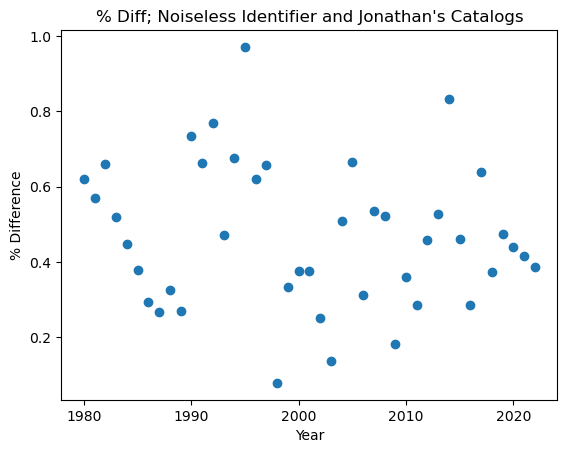

In [5]:
percent_diffs = diffs/num_px*100
years = np.arange(1980, 2023)

plt.scatter(x=years, y=percent_diffs)
plt.title('% Diff; Noiseless Identifier and Jonathan\'s Catalogs')
plt.xlabel('Year')
plt.ylabel('% Difference')

### Storm Counts

In [6]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = len(cur_df.cluster.value_counts().index) - 1
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Individual Storms')

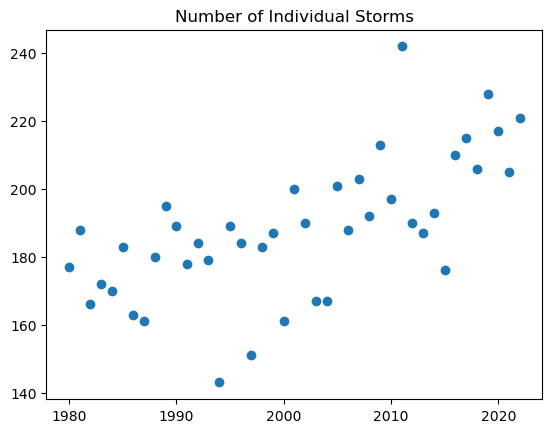

In [7]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Individual Storms')

In [27]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = cur_df.loc[cur_df.is_landfalling].cluster.value_counts().shape[0]
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Landfalling Storms')

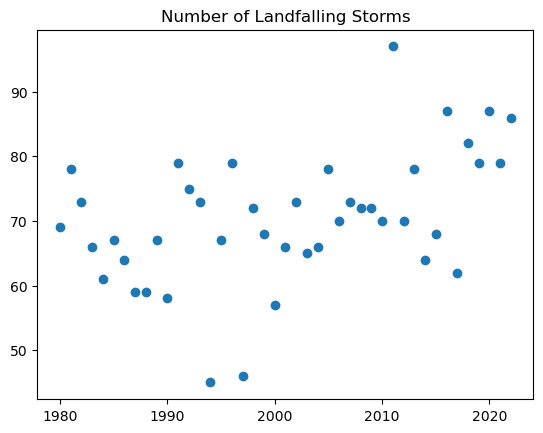

In [28]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Landfalling Storms')